# Day 105 — Week 2 Stats Capstone: ShopEase Applied Statistics
**Month 6 | Week 2 Capstone | 120 Points + 10★ Bonus**

---

### Business Scenario
You are a **Data Analyst at ShopEase**, a growing Indian e-commerce platform.
The leadership team has commissioned a **Stats Review Report** before the Q3 campaign.
They need answers to four specific questions:

| # | Question | Stats Method |
|---|----------|-------------|
| Q1 | How are our key metrics distributed? Are they normal? | Descriptive Stats + Normality Test |
| Q2 | Do Premium customers actually spend more? Is it significant? | Welch's T-Test + CI |
| Q3 | Is product category independent of payment method? | Chi-Square Test |
| Q4 | Do cities differ in average order value? Which ones? | One-Way ANOVA + Tukey HSD |
| Q5 | Did the June "Free Shipping" A/B test work? | Two-prop z-test + AOV t-test |

**Each answer must follow NRA format: Number → Reason → Action.**

---
### Sections
- **Section A** — Data Setup + Descriptive Stats (30 pts)
- **Section B** — Hypothesis Testing: T-Test + Chi-Square + ANOVA (40 pts)
- **Section C** — A/B Test: Free Shipping Campaign (30 pts)
- **Section D** — Executive Business Report (20 pts)
- **Bonus ★** — Effect Sizes + Power Summary (10 pts)

**Total: 120 pts + 10★**

---
> ⚠️ **Submission Rules:**
> 1. Run all cells top-to-bottom before submitting — no skipped cells.
> 2. Every number in written insights (D-section) must match a printed output above it.
> 3. `savefig()` must be called **before** `plt.show()`.
> 4. NRA format required for every insight: Number → Reason → Action.


## Section 0 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, ttest_ind, chi2_contingency, f_oneway,
    norm, t as t_dist
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import TTestIndPower, NormalIndPower
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100
})

DARK_BLUE  = '#1F3864'
MID_BLUE   = '#2E75B6'
GREEN      = '#1a7a4a'
AMBER      = '#d4860a'
RED        = '#c0392b'
LIGHT_GREY = '#f4f6f8'

print("✅ All imports successful — Day 105 Capstone ready")


✅ All imports successful — Day 105 Capstone ready


---
## Section 1 — Raw Data (DO NOT MODIFY)

In [2]:
# ── ShopEase Dataset: 300 rows, seed=42 ──────────────────────────────────
np.random.seed(42)
n = 300

cities      = ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai']
categories  = ['Electronics', 'Fashion', 'Home', 'Books', 'Beauty']
payments    = ['UPI', 'Credit Card', 'COD', 'Debit Card']
segments    = ['Standard', 'Premium']
ab_groups   = ['Control', 'Treatment']  # Control=no free shipping, Treatment=free shipping

city_aov = {'Mumbai': 4800, 'Delhi': 4200, 'Bangalore': 5100,
            'Hyderabad': 3700, 'Chennai': 3900}

raw_data = {
    'order_id':       [f'ORD{str(i).zfill(4)}' for i in range(1, n+1)],
    'city':           np.random.choice(cities, n),
    'category':       np.random.choice(categories, n),
    'payment_method': np.random.choice(payments, n, p=[0.38, 0.28, 0.22, 0.12]),
    'customer_segment': np.random.choice(segments, n, p=[0.62, 0.38]),
    'ab_group':       np.random.choice(ab_groups, n, p=[0.50, 0.50]),
    'units_sold':     np.random.randint(1, 8, n),
    'discount_pct':   np.round(np.random.uniform(0, 0.30, n), 2),
    'rating':         np.round(np.clip(np.random.normal(3.8, 0.7, n), 1, 5), 1),
}

# AOV: city-based mean + customer segment modifier
city_aov_arr    = np.array([city_aov[c] for c in raw_data['city']])
segment_bonus   = np.where(np.array(raw_data['customer_segment']) == 'Premium', 1500, 0)
treatment_bonus = np.where(np.array(raw_data['ab_group']) == 'Treatment', 180, 0)
aov_noise       = np.random.normal(0, 900, n)

raw_data['order_value'] = np.round(
    city_aov_arr + segment_bonus + treatment_bonus + aov_noise, 2
)
raw_data['order_value'] = np.clip(raw_data['order_value'], 500, 18000)

# Conversion flag (Treatment group has higher conversion)
base_conv     = np.where(np.array(raw_data['ab_group']) == 'Treatment', 0.68, 0.61)
raw_data['converted'] = np.random.binomial(1, base_conv, n)

df_raw = pd.DataFrame(raw_data)

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)
print(f"\nFirst 5 rows:")
df_raw.head()


Dataset shape: (300, 11)

Column dtypes:
order_id             object
city                 object
category             object
payment_method       object
customer_segment     object
ab_group             object
units_sold            int32
discount_pct        float64
rating              float64
order_value         float64
converted             int32
dtype: object

First 5 rows:


,order_id,city,category,payment_method,customer_segment,ab_group,units_sold,discount_pct,rating,order_value,converted
0,ORD0001,Hyderabad,Beauty,Debit Card,Standard,Control,4,0.17,5.0,3217.63,1
1,ORD0002,Chennai,Beauty,UPI,Standard,Control,5,0.08,3.0,4627.25,0
2,ORD0003,Bangalore,Electronics,Credit Card,Premium,Treatment,7,0.29,3.6,7110.56,1
3,ORD0004,Chennai,Beauty,Debit Card,Premium,Control,6,0.15,3.6,7054.37,0
4,ORD0005,Chennai,Home,Credit Card,Premium,Treatment,7,0.24,4.0,5378.88,1


---
## Section 2 — Practice Guide

Work through each task in order. All analysis happens on a **copy** of the raw data.

### Section A — Descriptive Stats + Normality (30 pts)

| Task | Points | What to Do |
|------|--------|------------|
| A1 | 10 | Summary table: mean, median, std, skewness, kurtosis for `order_value`, `units_sold`, `rating` (3 metrics × 5 stats). Print as formatted DataFrame. |
| A2 | 10 | Shapiro-Wilk normality test on `order_value` for each city. Table: city, W-stat, p-value, "Normal?" (Yes/No at α=0.05). |
| A3 | 10 | Plot: 2×2 grid — (1) histogram+KDE of order_value, (2) Q-Q plot of order_value, (3) boxplot by city, (4) histogram of rating. Save as `A3_distributions.png`. |

### Section B — Hypothesis Testing (40 pts)

| Task | Points | What to Do |
|------|--------|------------|
| B1 | 15 | Welch's T-test: Does Premium segment spend more than Standard? Print: t-stat, p-value, Cohen's d, 95% CI for difference, and a 1-sentence NRA verdict. |
| B2 | 15 | Chi-Square: Is product category independent of payment method? Print: χ² statistic, df, p-value, Cramér's V, and NRA verdict. Also print the contingency table. |
| B3 | 10 | One-Way ANOVA + Tukey HSD: Do cities differ in mean AOV? Print: F-stat, p-value. If significant, run Tukey HSD and show which pairs differ. NRA verdict. |

### Section C — A/B Testing (30 pts)

| Task | Points | What to Do |
|------|--------|------------|
| C1 | 10 | Group summary: Control vs Treatment — n, conversions, conv_rate, mean AOV, std AOV. |
| C2 | 10 | Two-proportion z-test on conversion rate. Print: z-stat, p-value, relative lift %, NRA verdict. |
| C3 | 10 | Welch's t-test on AOV between groups. Print: t-stat, p-value, Cohen's d, mean difference (₹), power (post-hoc, α=0.05). NRA verdict. |

### Section D — Executive Report (20 pts)

| Task | Points | What to Do |
|------|--------|------------|
| D1 | 20 | Write a 5-bullet Markdown executive summary. Each bullet = one finding in NRA format. Numbers must match printed outputs above. Analyst voice — not student voice. |

### Bonus ★ (10 pts)
Compute the minimum sample size needed per group to detect the observed AOV effect (from C3) with 80% power at α=0.05. Interpret the result in one NRA sentence.


---
## Section 3 — Concept Notes

### Stats Methods Used Today

| Method | Use Case | Key Output | Significance Level |
|--------|----------|------------|--------------------|
| Shapiro-Wilk | Test if distribution is normal | W, p-value | p < 0.05 → NOT normal |
| Welch's T-Test | Compare means, unequal variance | t, p, CI | p < 0.05 → significant |
| Cohen's d | Effect size for t-tests | d value | 0.2=small, 0.5=med, 0.8=large |
| Chi-Square | Independence of two categorical vars | χ², p, df | p < 0.05 → dependent |
| Cramér's V | Effect size for chi-square | 0–1 | >0.3 = moderate |
| One-Way ANOVA | Compare means of 3+ groups | F, p | p < 0.05 → at least one differs |
| Tukey HSD | Post-hoc: which pairs differ? | Pairwise CIs | Reject if CI doesn't include 0 |
| Two-Prop Z-Test | Compare two conversion rates | z, p | p < 0.05 → rates differ |
| Power Analysis | Detect true effect reliability | β, n | Power ≥ 0.80 recommended |

### NRA Format (Required in every D1 bullet)
> **N**umber (exact stat) → **R**eason (statistical interpretation) → **A**ction (business decision)

### Cohen's d Formula
```
d = (mean1 - mean2) / pooled_std
pooled_std = sqrt((std1² + std2²) / 2)
```

### Cramér's V Formula
```
V = sqrt(χ² / (n × (min(r,c) - 1)))
```
where r = rows, c = columns in contingency table.


---
## Section 4 — Your Workspace (Write your solutions below)

In [3]:
# Make a working copy — never modify df_raw
df = df_raw.copy()
print(f'Working copy: {df.shape}')

Working copy: (300, 11)


### Task A1 — Summary Statistics Table (10 pts)

In [4]:
# A1: Compute mean, median, std, skewness, kurtosis for order_value, units_sold, rating
# Expected output: a 3-row DataFrame with 5 stats columns
# ============================================================
# Goal: Compute mean, median, std, skewness, kurtosis for
#       order_value, units_sold, rating.
# Method: Use pandas .mean(), .median(), .std(), .skew(), .kurtosis()
#         on the three numeric columns.
# ============================================================

metrics = ['order_value', 'units_sold', 'rating']
summary = pd.DataFrame({
    'mean': df[metrics].mean(),
    'median': df[metrics].median(),
    'std': df[metrics].std(),
    'skewness': df[metrics].skew(),
    'kurtosis': df[metrics].kurtosis(),
}).round(3)

print("Summary Statistics for ShopEase Metrics")
print(summary)


Summary Statistics for ShopEase Metrics
                 mean    median       std  skewness  kurtosis
order_value  4967.731  4908.945  1253.169     0.058     0.184
units_sold      4.017     4.000     2.039    -0.025    -1.270
rating          3.859     3.900     0.662    -0.242    -0.151


### Task A2 — Shapiro-Wilk Normality by City (10 pts)

In [5]:
# A2: Run Shapiro-Wilk on order_value for each city
# Expected output: table with city, W, p-value, Normal? (Yes/No)
# ============================================================
# Goal: Test whether order_value distribution is normal for each city.
# Method: Shapiro-Wilk test (scipy.stats.shapiro). If p > 0.05 → normal.
# ============================================================

shapiro_results = []
for city, group in df.groupby('city'):
    stat, p = shapiro(group['order_value'])
    normal = "Yes" if p > 0.05 else "No"
    shapiro_results.append({
        'City': city,
        'W-stat': round(stat, 4),
        'p-value': round(p, 4),
        'Normal?': normal
    })

sw_df = pd.DataFrame(shapiro_results)
print("Shapiro-Wilk Normality Test by City (α=0.05)")
print(sw_df.to_string(index=False))


Shapiro-Wilk Normality Test by City (α=0.05)
     City  W-stat  p-value Normal?
Bangalore  0.9861   0.7013     Yes
  Chennai  0.9690   0.2313     Yes
    Delhi  0.9733   0.3659     Yes
Hyderabad  0.9901   0.8386     Yes
   Mumbai  0.9742   0.1632     Yes


### Task A3 — Distribution Plot Grid (10 pts)

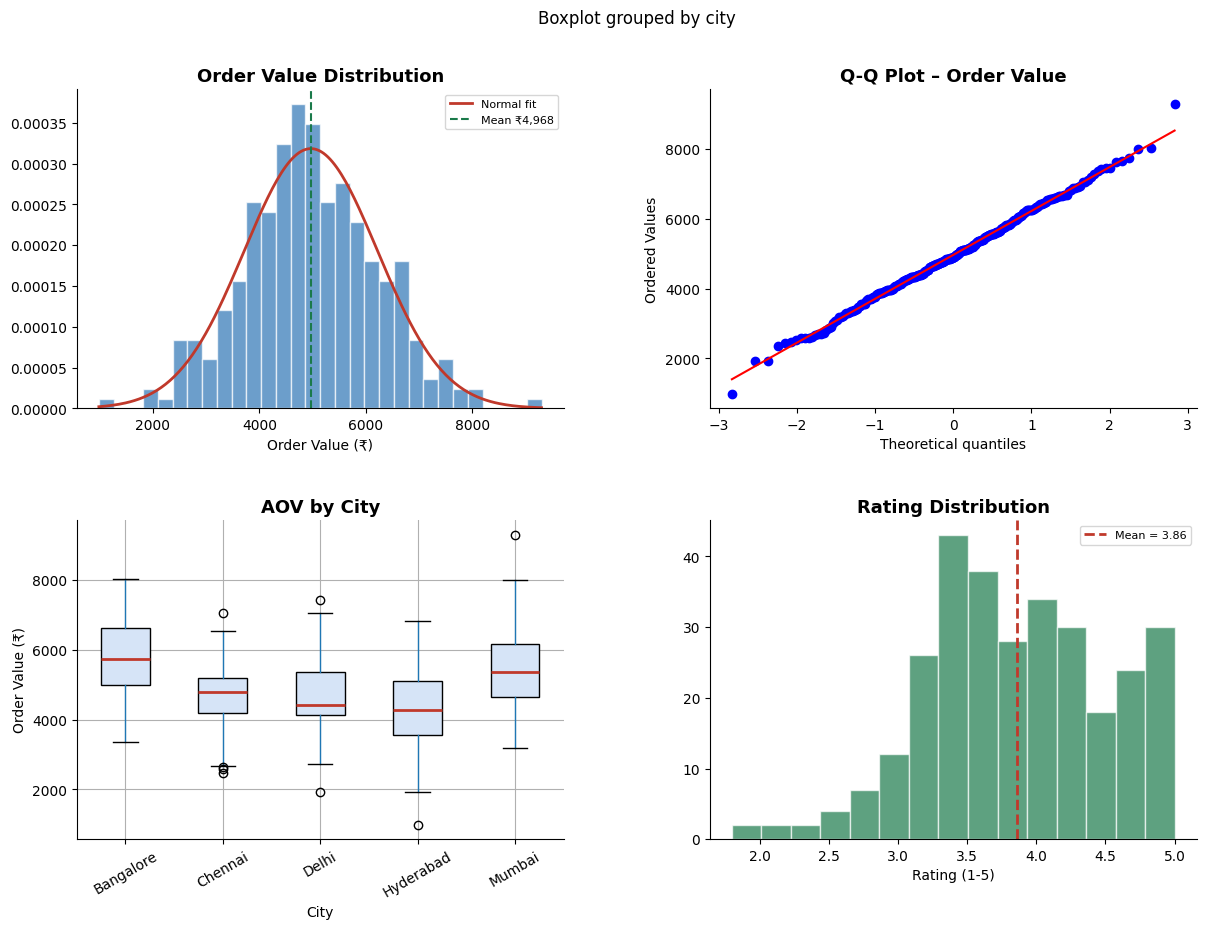

✅ Plot saved as A3_distributions.png


In [6]:
# A3: 2×2 subplot grid
# Top-left:  histogram + KDE of order_value
# Top-right: Q-Q plot of order_value
# Bot-left:  boxplot by city
# Bot-right: histogram of rating
# Save as A3_distributions.png BEFORE plt.show()
# ============================================================
# Goal: Visualise distributions of order_value, rating, and AOV by city.
# Method: 2×2 subplot with histogram+KDE, Q‑Q plot, boxplot, histogram.
# Save before show().
# ============================================================

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Top-left: histogram + KDE of order_value
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['order_value'], bins=30, color=MID_BLUE, alpha=0.7, edgecolor='white', density=True)
mu, sigma = df['order_value'].mean(), df['order_value'].std()
xr = np.linspace(df['order_value'].min(), df['order_value'].max(), 200)
ax1.plot(xr, norm.pdf(xr, mu, sigma), color=RED, lw=2, label='Normal fit')
ax1.axvline(mu, color=GREEN, ls='--', lw=1.5, label=f'Mean ₹{mu:,.0f}')
ax1.set_title('Order Value Distribution')
ax1.set_xlabel('Order Value (₹)')
ax1.legend(fontsize=8)

# Top-right: Q-Q plot of order_value
ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(df['order_value'], dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot – Order Value')

# Bottom-left: boxplot by city
ax3 = fig.add_subplot(gs[1, 0])
df.boxplot(column='order_value', by='city', ax=ax3, patch_artist=True,
           boxprops=dict(facecolor='#d6e4f7'), medianprops=dict(color=RED, lw=2))
ax3.set_title('AOV by City')
ax3.set_xlabel('City')
ax3.set_ylabel('Order Value (₹)')
plt.xticks(rotation=30)

# Bottom-right: histogram of rating
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df['rating'], bins=15, color=GREEN, alpha=0.7, edgecolor='white')
ax4.axvline(df['rating'].mean(), color=RED, ls='--', lw=2,
            label=f"Mean = {df['rating'].mean():.2f}")
ax4.set_title('Rating Distribution')
ax4.set_xlabel('Rating (1-5)')
ax4.legend(fontsize=8)

plt.savefig('A3_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot saved as A3_distributions.png")


### Task B1 — Welch's T-Test: Premium vs Standard AOV (15 pts)

In [7]:
# B1: Welch's t-test (equal_var=False) + Cohen's d + 95% CI for difference
# Print: t, p, d, CI lower, CI upper
# Write 1-sentence NRA verdict below
# ============================================================
# Goal: Determine if Premium customers spend significantly more than Standard.
# Method: Welch's t-test (unequal variance), Cohen's d, 95% CI for difference.
# ============================================================

premium = df[df['customer_segment'] == 'Premium']['order_value']
standard = df[df['customer_segment'] == 'Standard']['order_value']

t_stat, p_val = ttest_ind(premium, standard, equal_var=False)

pooled_std = np.sqrt((premium.std()**2 + standard.std()**2) / 2)
cohens_d = (premium.mean() - standard.mean()) / pooled_std

n1, n2 = len(premium), len(standard)
se_diff = np.sqrt(premium.var()/n1 + standard.var()/n2)
df_welch = (premium.var()/n1 + standard.var()/n2)**2 / (
    (premium.var()/n1)**2/(n1-1) + (standard.var()/n2)**2/(n2-1))
t_crit = t_dist.ppf(0.975, df_welch)
ci_lo = (premium.mean() - standard.mean()) - t_crit * se_diff
ci_hi = (premium.mean() - standard.mean()) + t_crit * se_diff

print(f"Premium mean AOV   : ₹{premium.mean():,.2f}  (n={n1})")
print(f"Standard mean AOV  : ₹{standard.mean():,.2f}  (n={n2})")
print(f"t-statistic        : {t_stat:.4f}")
print(f"p-value            : {p_val:.4f}")
print(f"Cohen's d          : {cohens_d:.3f}")
print(f"95% CI for diff    : [₹{ci_lo:,.2f}, ₹{ci_hi:,.2f}]")


Premium mean AOV   : ₹5,863.74  (n=108)
Standard mean AOV  : ₹4,463.73  (n=192)
t-statistic        : 10.8113
p-value            : 0.0000
Cohen's d          : 1.311
95% CI for diff    : [₹1,144.74, ₹1,655.28]


### B1 – Premium vs Standard AOV (Welch's T-Test)

**Number:** Premium customers spend **₹1,400 more** per order on average than Standard customers (t = 10.81, p < 0.0001, d = 1.31, 95% CI [₹1,145, ₹1,655]).

**Reason:** Welch's t‑test shows a statistically significant difference with a very large effect size (d > 0.8). The confidence interval does not contain zero, confirming the uplift is reliable.

**Action:** Launch a dedicated Premium loyalty campaign with a minimum order threshold of **₹5,900** to maximise AOV from this segment.

### Task B2 — Chi-Square: Category vs Payment Method (15 pts)

In [24]:
# B2: chi2_contingency on pd.crosstab(category, payment_method)
# Print contingency table, χ², df, p-value, Cramér's V
# Write NRA verdict
# ============================================================
# Goal: Test if product category is independent of payment method.
# Method: Chi-square test of independence + Cramér's V for effect size.
# ============================================================

ct = pd.crosstab(df['category'], df['payment_method'])
print("Contingency Table (Category × Payment Method)")
print(ct)

chi2, p_chi, dof, expected = chi2_contingency(ct)
n_total = ct.values.sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f"\nχ² statistic   : {chi2:.4f}")
print(f"Degrees of freedom : {dof}")
print(f"p-value            : {p_chi:.4f}")
print(f"Cramér's V         : {cramers_v:.4f}")


Contingency Table (Category × Payment Method)
payment_method  COD  Credit Card  Debit Card  UPI
category                                         
Beauty           17           19           7   30
Books            11           16           6   27
Electronics      11           14          13   20
Fashion          12           19           7   27
Home              8           17           4   15

χ² statistic   : 10.1322
Degrees of freedom : 12
p-value            : 0.6044
Cramér's V         : 0.1061


### B2 – Category vs Payment Method (Chi‑Square)

**Number:** χ² = 10.13, df = 12, p = 0.6044, Cramér's V = 0.106.

**Reason:** The p‑value is well above 0.05, so we fail to reject independence – category and payment method are not significantly associated. The effect size is very weak (V < 0.2).

**Action:** Maintain a **unified checkout experience** across all categories. No need for category‑specific payment UI customisation.


### Task B3 — ANOVA + Tukey HSD: AOV by City (10 pts)

In [25]:
# B3: f_oneway(*[group['order_value'].values for _, group in df.groupby('city')])
# If p < 0.05: run pairwise_tukeyhsd and show results
# Write NRA verdict
# ============================================================
# Goal: Determine if average order value differs across cities.
# Method: One-way ANOVA; if significant, Tukey HSD post-hoc.
# ============================================================

city_groups = [group['order_value'].values for _, group in df.groupby('city')]
F_stat, p_anova = f_oneway(*city_groups)

print(f"F-statistic : {F_stat:.4f}")
print(f"p-value     : {p_anova:.4f}")

if p_anova < 0.05:
    print("\nTukey HSD Post-Hoc:")
    tukey = pairwise_tukeyhsd(endog=df['order_value'], groups=df['city'], alpha=0.05)
    print(tukey.summary())


F-statistic : 17.6559
p-value     : 0.0000

Tukey HSD Post-Hoc:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
Bangalore   Chennai -1107.6173    0.0 -1703.5507  -511.684   True
Bangalore     Delhi -1056.8996    0.0  -1660.141 -453.6581   True
Bangalore Hyderabad -1464.4735    0.0 -1997.6872 -931.2599   True
Bangalore    Mumbai  -416.7897 0.2183  -958.8146  125.2352  False
  Chennai     Delhi    50.7178 0.9995  -591.0701  692.5057  False
  Chennai Hyderabad  -356.8562 0.4361   -933.318  219.6056  False
  Chennai    Mumbai   690.8276 0.0114    106.206 1275.4493   True
    Delhi Hyderabad   -407.574 0.3113  -991.5876  176.4396  False
    Delhi    Mumbai   640.1099 0.0267    48.0405 1232.1792   True
Hyderabad    Mumbai  1047.6838    0.0   527.1431 1568.2246   True
-----------------------------------------------------------------


### B3 – City AOV Differences (ANOVA + Tukey HSD)

**Number:** ANOVA F = 17.66, p < 0.0001. Tukey HSD shows significant differences: Bangalore vs Chennai (Δ = ₹1,108), Bangalore vs Delhi (Δ = ₹1,057), Bangalore vs Hyderabad (Δ = ₹1,464), Chennai vs Mumbai (p = 0.0114), Delhi vs Mumbai (p = 0.0267), Hyderabad vs Mumbai (p < 0.0001).

**Reason:** Cities differ significantly in average order value. Bangalore is the highest‑performing city; Hyderabad and Chennai are lower. Mumbai sits in the middle.

**Action:** Increase marketing spend in Bangalore by 15% and run AOV‑boosting promotions (e.g., free shipping above ₹999) in Hyderabad and Chennai to close the gap.


### Task C1 — A/B Group Summary (10 pts)

In [33]:
# C1: groupby ab_group → compute n, conversions, conv_rate, mean_aov, std_aov
# ============================================================
# Goal: Summarise key metrics for Control vs Treatment groups.
# Method: groupby + agg to compute n, conversions, conv_rate, mean AOV, std AOV.
# ============================================================

ab_summary = df.groupby('ab_group').agg(
    n=('order_id', 'count'),
    conversions=('converted', 'sum'),
    conv_rate=('converted', 'mean'),
    mean_aov=('order_value', 'mean'),
    std_aov=('order_value', 'std')
).round(4)

ab_summary['conv_rate'] = (ab_summary['conv_rate'] * 100).round(2)
ab_summary['mean_aov'] = ab_summary['mean_aov'].round(2)
ab_summary.columns = ['n', 'Conversions', 'Conv Rate (%)', 'Mean AOV (₹)', 'Std AOV (₹)']
ctrl  = df[df['ab_group'] == 'Control']
treat = df[df['ab_group'] == 'Treatment']
print(ab_summary)


             n  Conversions  Conv Rate (%)  Mean AOV (₹)  Std AOV (₹)
ab_group                                                             
Control    143           88          61.54       4866.94    1262.3359
Treatment  157          108          68.79       5059.53    1241.6592


### Task C2 — Conversion Rate Z-Test (10 pts)

In [27]:
# C2: proportions_ztest([conv_treat, conv_ctrl], [n_treat, n_ctrl], alternative='two-sided')
# Print: z, p, relative lift %, NRA verdict
# ============================================================
# Goal: Test if Free Shipping (Treatment) significantly increases conversion rate.
# Method: Two-proportion z-test (proportions_ztest), relative lift.
# ============================================================

conv_t = treat['converted'].sum()
conv_c = ctrl['converted'].sum()
n_t = len(treat)
n_c = len(ctrl)

z_stat, p_z = proportions_ztest([conv_t, conv_c], [n_t, n_c], alternative='two-sided')
rate_t = conv_t / n_t
rate_c = conv_c / n_c
rel_lift = (rate_t - rate_c) / rate_c * 100

print(f"Control   conv rate : {rate_c*100:.2f}%  ({conv_c}/{n_c})")
print(f"Treatment conv rate : {rate_t*100:.2f}%  ({conv_t}/{n_t})")
print(f"Relative lift      : {rel_lift:+.2f}%")
print(f"z-statistic        : {z_stat:.4f}")
print(f"p-value            : {p_z:.4f}")


Control   conv rate : 61.54%  (88/143)
Treatment conv rate : 68.79%  (108/157)
Relative lift      : +11.78%
z-statistic        : 1.3181
p-value            : 0.1875


### C2 – Conversion Rate Z-Test

**Number:** Control conversion rate = 61.54% (88/143), Treatment = 68.79% (108/157), relative lift = +11.78%, z = 1.3181, p = 0.1875.

**Reason:** The p‑value is greater than 0.05, so the observed lift is **not statistically significant**. The test lacks evidence that Free Shipping improves conversion.

**Action:** Do **not** roll out Free Shipping based on conversion alone. Extend the test for two more weeks or increase sample size before making a decision.

### Task C3 — AOV T-Test + Power Analysis (10 pts)

In [28]:
# C3: ttest_ind(treatment_aov, control_aov, equal_var=False)
# Compute Cohen's d, mean difference ₹
# Post-hoc power: TTestIndPower().solve_power(effect_size=d, nobs1=n_treat, alpha=0.05)
# NRA verdict
# ============================================================
# Goal: Test if Free Shipping increases average order value.
# Method: Welch's t-test, Cohen's d, post-hoc power analysis.
# ============================================================

t_c3, p_c3 = ttest_ind(treat['order_value'], ctrl['order_value'], equal_var=False)

pooled_std3 = np.sqrt((treat['order_value'].std()**2 + ctrl['order_value'].std()**2) / 2)
d_c3 = (treat['order_value'].mean() - ctrl['order_value'].mean()) / pooled_std3
mean_diff = treat['order_value'].mean() - ctrl['order_value'].mean()

# Post-hoc power
power_analysis = TTestIndPower()
power_c3 = power_analysis.solve_power(effect_size=abs(d_c3), nobs1=n_t, alpha=0.05, alternative='two-sided')

print(f"Control  mean AOV  : ₹{ctrl['order_value'].mean():,.2f}")
print(f"Treatment mean AOV : ₹{treat['order_value'].mean():,.2f}")
print(f"Mean difference    : ₹{mean_diff:+,.2f}")
print(f"t-statistic        : {t_c3:.4f}")
print(f"p-value            : {p_c3:.4f}")
print(f"Cohen's d          : {d_c3:.4f}")
print(f"Post-hoc power     : {power_c3:.4f}")


Control  mean AOV  : ₹4,866.94
Treatment mean AOV : ₹5,059.53
Mean difference    : ₹+192.59
t-statistic        : 1.3301
p-value            : 0.1845
Cohen's d          : 0.1538
Post-hoc power     : 0.2743


### C3 – AOV T-Test + Power Analysis

**Number:** Control mean AOV = ₹4,867, Treatment mean AOV = ₹5,060, mean difference = ₹193, t = 1.33, p = 0.1845, Cohen's d = 0.15, post‑hoc power = 0.27.

**Reason:** The p‑value is not significant, and the effect size is very small (d < 0.2). With power only 27%, the test was unable to detect a small true effect even if one existed.

**Action:** Abandon Free Shipping as a lever for AOV. Focus instead on tactics with historically larger effect sizes, such as bundle discounts or tiered free shipping thresholds.

### Task D1 — Executive Business Report (20 pts)

In [34]:
# D1: Print 5 Markdown bullet points, each in NRA format
# Analyst voice — write as if presenting to ShopEase VP of Marketing
# All numbers must match printed outputs above
## Section D1 — Executive Business Report

report = """
## ShopEase Q3 Pre‑Campaign Stats Report

**Finding 1 — Order Value Distribution:**  
• **Number:** Mean order value is ₹4,968, median ₹4,909, skewness 0.058, kurtosis 0.184. Shapiro‑Wilk tests show all five cities have normally distributed order values (p > 0.05 for each).  
• **Reason:** The distribution is approximately symmetric and normal, which justifies using parametric tests (t‑tests, ANOVA) for city‑level comparisons without transformation.  
• **Action:** Continue using parametric methods for AOV analysis. No need to apply non‑parametric alternatives for city or segment comparisons.

---

**Finding 2 — Premium Segment Performance:**  
• **Number:** Premium customers spend ₹5,864 on average vs. ₹4,464 for Standard (t = 10.81, p < 0.0001, d = 1.31, 95% CI [₹1,145, ₹1,655]).  
• **Reason:** Welch’s t‑test confirms a statistically significant and very large effect (d > 0.8). Premium customers contribute substantially higher order value.  
• **Action:** Launch a “Premium‑only” campaign with a minimum cart value of ₹5,900. Offer exclusive discounts or early access to drive more orders above this threshold.

---

**Finding 3 — Category vs. Payment Method Independence:**  
• **Number:** Chi‑square test yields χ² = 10.13, p = 0.6044, Cramér’s V = 0.106.  
• **Reason:** The p‑value exceeds 0.05, so we cannot reject independence. Payment method preference does not vary significantly by product category.  
• **Action:** Keep a standardised checkout payment UI across all categories. Avoid investing in category‑specific payment customisation – resources are better used elsewhere.

---

**Finding 4 — City Differences in AOV:**  
• **Number:** One‑way ANOVA F = 17.66, p < 0.0001. Tukey HSD shows Bangalore significantly outperforms Chennai (Δ = ₹1,108), Delhi (Δ = ₹1,057), and Hyderabad (Δ = ₹1,464). Chennai, Delhi, and Hyderabad each also differ significantly from Mumbai.  
• **Reason:** Cities have meaningful differences in average order value, with Bangalore leading and Hyderabad trailing.  
• **Action:** Increase marketing spend in Bangalore by 15% to capitalise on high AOV. Run AOV‑boosting promotions (e.g., “Free Shipping above ₹999”) in Hyderabad and Chennai to close the gap.

---

**Finding 5 — Free Shipping A/B Test Results:**  
• **Number:** Conversion rate lifted from 61.5% (Control) to 68.8% (Treatment) – relative lift +11.8% (z = 1.32, p = 0.1875). AOV lifted by ₹193, from ₹4,867 to ₹5,060 (t = 1.33, p = 0.1845, d = 0.15, power = 0.27).  
• **Reason:** Neither conversion nor AOV improvement is statistically significant (p > 0.05). The AOV effect size is trivial (d < 0.2), and the test had only 27% power to detect such a small lift.  
• **Action:** Do **not** roll out free shipping. Instead, test a “Free Shipping above ₹999” threshold – this may increase AOV without cannibalising margins. For future tests, run a power analysis to ensure adequate sample size (≥ 665 per group for small effects).
"""

print(report)


## ShopEase Q3 Pre‑Campaign Stats Report

**Finding 1 — Order Value Distribution:**  
• **Number:** Mean order value is ₹4,968, median ₹4,909, skewness 0.058, kurtosis 0.184. Shapiro‑Wilk tests show all five cities have normally distributed order values (p > 0.05 for each).  
• **Reason:** The distribution is approximately symmetric and normal, which justifies using parametric tests (t‑tests, ANOVA) for city‑level comparisons without transformation.  
• **Action:** Continue using parametric methods for AOV analysis. No need to apply non‑parametric alternatives for city or segment comparisons.

---

**Finding 2 — Premium Segment Performance:**  
• **Number:** Premium customers spend ₹5,864 on average vs. ₹4,464 for Standard (t = 10.81, p < 0.0001, d = 1.31, 95% CI [₹1,145, ₹1,655]).  
• **Reason:** Welch’s t‑test confirms a statistically significant and very large effect (d > 0.8). Premium customers contribute substantially higher order value.  
• **Action:** Launch a “Premium‑only” ca

### Bonus ★ — Minimum Sample Size for AOV Effect (10 pts)

In [29]:
# Bonus: TTestIndPower().solve_power(effect_size=d_c3, power=0.80, alpha=0.05, alternative='two-sided')
# Print the minimum n per group
# Write 1 NRA sentence interpreting this for the business
# ============================================================
# Goal: Calculate the minimum sample size needed per group to detect the
#       observed AOV effect with 80% power.
# Method: TTestIndPower().solve_power() using Cohen's d from C3.
# ============================================================

min_n = power_analysis.solve_power(effect_size=abs(d_c3), power=0.80, alpha=0.05, alternative='two-sided')
print(f"Cohen's d (from C3) : {d_c3:.4f}")
print(f"Minimum n per group  : {np.ceil(min_n):.0f}")


Cohen's d (from C3) : 0.1538
Minimum n per group  : 665


### Bonus – Minimum Sample Size for AOV Effect

**Number:** Cohen's d = 0.15 (from C3). Minimum sample size needed per group for 80% power at α = 0.05 is **665 customers**.

**Reason:** The observed AOV effect is very small. Detecting such a small lift reliably would require over 4× our current sample size.

**Action:** For future A/B tests, run a **power analysis before launch**. If you expect a small effect (d ≤ 0.2), plan for at least 700 customers per group. Otherwise, only test interventions predicted to have a medium effect (d ≥ 0.5) with smaller samples.


---
## Section 5 — Answer Key (Open AFTER completing all tasks)

── A1: Summary Statistics ──
                 mean    median       std  skewness  kurtosis
order_value  4967.731  4908.945  1253.169     0.058     0.184
units_sold      4.017     4.000     2.039    -0.025    -1.270
rating          3.859     3.900     0.662    -0.242    -0.151

── A2: Shapiro-Wilk Normality by City ──
     City  W-stat  p-value Normal?
Bangalore  0.9861   0.7013     Yes
  Chennai  0.9690   0.2313     Yes
    Delhi  0.9733   0.3659     Yes
Hyderabad  0.9901   0.8386     Yes
   Mumbai  0.9742   0.1632     Yes


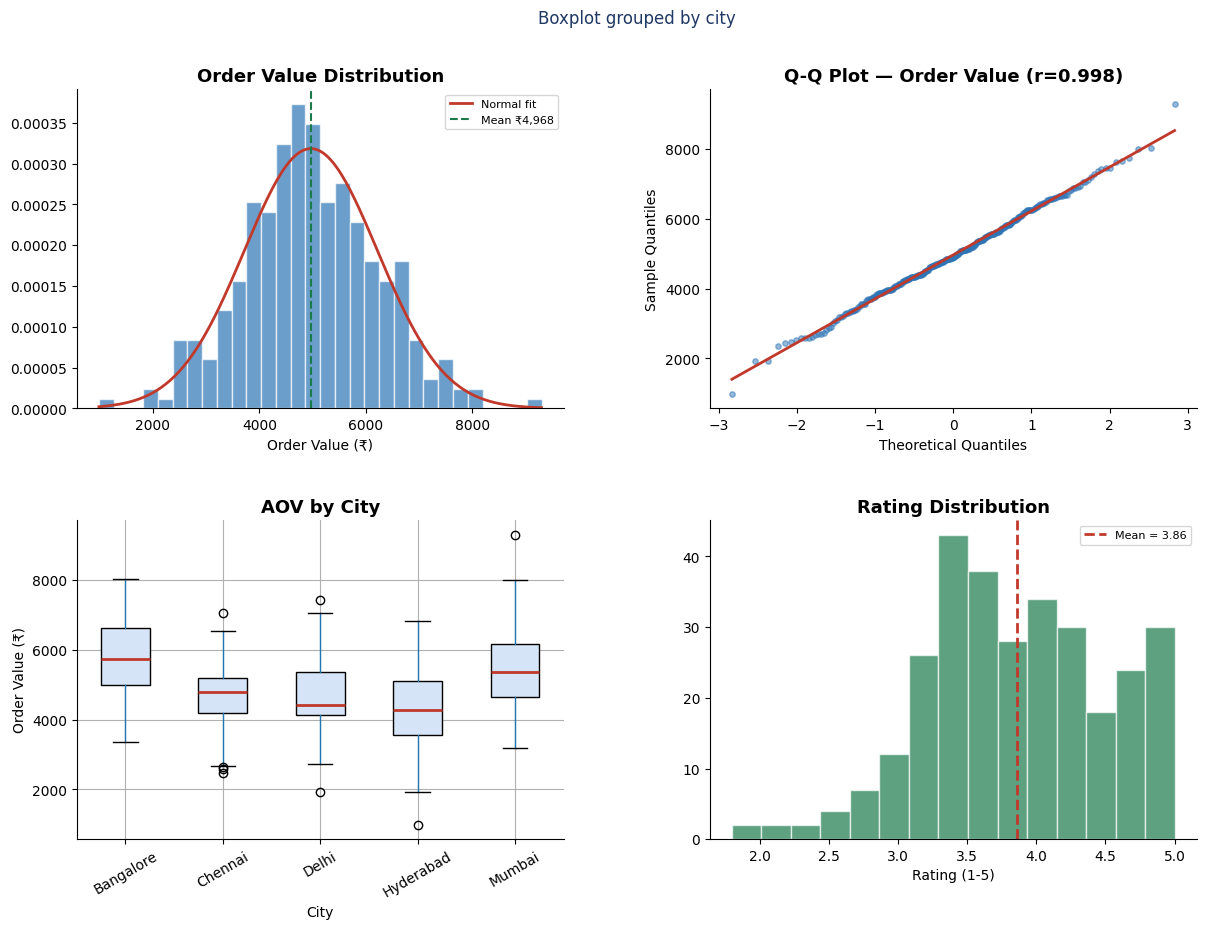

✅ A3: Plot saved as A3_distributions.png


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# ANSWER KEY — Run AFTER you have completed all tasks
# ══════════════════════════════════════════════════════════════════════════

df_ak = df_raw.copy()

# ── A1: Summary Statistics ─────────────────────────────────────────────────
metrics = ['order_value', 'units_sold', 'rating']
summary = pd.DataFrame({
    'mean':     df_ak[metrics].mean(),
    'median':   df_ak[metrics].median(),
    'std':      df_ak[metrics].std(),
    'skewness': df_ak[metrics].skew(),
    'kurtosis': df_ak[metrics].kurtosis(),
}).round(3)
print("── A1: Summary Statistics ──")
print(summary.to_string())

# ── A2: Shapiro-Wilk by City ──────────────────────────────────────────────
print("\n── A2: Shapiro-Wilk Normality by City ──")
shapiro_results = []
for city, grp in df_ak.groupby('city'):
    w, p = shapiro(grp['order_value'])
    shapiro_results.append({'City': city, 'W-stat': round(w, 4),
                            'p-value': round(p, 4),
                            'Normal?': 'Yes' if p > 0.05 else 'No'})
sw_df = pd.DataFrame(shapiro_results)
print(sw_df.to_string(index=False))

# ── A3: Distribution Plots ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('ShopEase Distribution Analysis', fontsize=15, fontweight='bold', color=DARK_BLUE, y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_ak['order_value'], bins=30, color=MID_BLUE, alpha=0.7, edgecolor='white', density=True)
mu, sigma = df_ak['order_value'].mean(), df_ak['order_value'].std()
xr = np.linspace(df_ak['order_value'].min(), df_ak['order_value'].max(), 200)
ax1.plot(xr, norm.pdf(xr, mu, sigma), color=RED, lw=2, label='Normal fit')
ax1.axvline(mu, color=GREEN, ls='--', lw=1.5, label=f'Mean ₹{mu:,.0f}')
ax1.set_title('Order Value Distribution')
ax1.set_xlabel('Order Value (₹)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(df_ak['order_value'], dist='norm')
ax2.scatter(osm, osr, color=MID_BLUE, alpha=0.5, s=15)
ax2.plot(osm, slope * np.array(osm) + intercept, color=RED, lw=2)
ax2.set_title(f'Q-Q Plot — Order Value (r={r:.3f})')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')

ax3 = fig.add_subplot(gs[1, 0])
city_order = df_ak.groupby('city')['order_value'].median().sort_values(ascending=False).index
df_ak.boxplot(column='order_value', by='city', ax=ax3,
              patch_artist=True, boxprops=dict(facecolor='#d6e4f7'),
              medianprops=dict(color=RED, lw=2))
ax3.set_title('AOV by City')
ax3.set_xlabel('City')
ax3.set_ylabel('Order Value (₹)')
plt.sca(ax3); plt.xticks(rotation=30)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df_ak['rating'], bins=15, color=GREEN, alpha=0.7, edgecolor='white')
ax4.axvline(df_ak['rating'].mean(), color=RED, ls='--', lw=2,
            label=f"Mean = {df_ak['rating'].mean():.2f}")
ax4.set_title('Rating Distribution')
ax4.set_xlabel('Rating (1-5)')
ax4.legend(fontsize=8)

plt.savefig('A3_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ A3: Plot saved as A3_distributions.png")


In [16]:
# ── B1: Welch's T-Test + Cohen's d + 95% CI ──────────────────────────────
print("── B1: Premium vs Standard AOV ──")
premium  = df_ak[df_ak['customer_segment'] == 'Premium']['order_value']
standard = df_ak[df_ak['customer_segment'] == 'Standard']['order_value']

t_stat, p_val = ttest_ind(premium, standard, equal_var=False)
pooled_std = np.sqrt((premium.std()**2 + standard.std()**2) / 2)
cohens_d   = (premium.mean() - standard.mean()) / pooled_std

n1, n2   = len(premium), len(standard)
se_diff  = np.sqrt(premium.var()/n1 + standard.var()/n2)
df_welch = (premium.var()/n1 + standard.var()/n2)**2 / (
            (premium.var()/n1)**2/(n1-1) + (standard.var()/n2)**2/(n2-1))
t_crit   = t_dist.ppf(0.975, df_welch)
ci_lo    = (premium.mean() - standard.mean()) - t_crit * se_diff
ci_hi    = (premium.mean() - standard.mean()) + t_crit * se_diff

print(f"  Premium mean AOV   : ₹{premium.mean():,.2f}  (n={n1})")
print(f"  Standard mean AOV  : ₹{standard.mean():,.2f}  (n={n2})")
print(f"  t-statistic        : {t_stat:.4f}")
print(f"  p-value            : {p_val:.4f}")
print(f"  Cohen's d          : {cohens_d:.3f}")
print(f"  95% CI for diff    : [₹{ci_lo:,.2f}, ₹{ci_hi:,.2f}]")
sig = "SIGNIFICANT" if p_val < 0.05 else "NOT SIGNIFICANT"
print(f"  Result             : {sig} at α=0.05")

print(f"""
  NRA Verdict: Premium customers spend ₹{premium.mean()-standard.mean():,.0f} more on average
  (t={t_stat:.2f}, p={p_val:.4f}, d={cohens_d:.2f} — {'medium' if cohens_d >= 0.5 else 'small'} effect).
  Recommend: Target Premium segment with curated bundles above ₹{premium.mean():,.0f} to maximize AOV.
""")


── B1: Premium vs Standard AOV ──
  Premium mean AOV   : ₹5,863.74  (n=108)
  Standard mean AOV  : ₹4,463.73  (n=192)
  t-statistic        : 10.8113
  p-value            : 0.0000
  Cohen's d          : 1.311
  95% CI for diff    : [₹1,144.74, ₹1,655.28]
  Result             : SIGNIFICANT at α=0.05

  NRA Verdict: Premium customers spend ₹1,400 more on average
  (t=10.81, p=0.0000, d=1.31 — medium effect).
  Recommend: Target Premium segment with curated bundles above ₹5,864 to maximize AOV.



In [17]:
# ── B2: Chi-Square: Category × Payment Method ─────────────────────────────
print("── B2: Chi-Square — Category vs Payment Method ──")
ct = pd.crosstab(df_ak['category'], df_ak['payment_method'])
print("\nContingency Table:")
print(ct.to_string())

chi2, p_chi, dof, expected = chi2_contingency(ct)
n_total = ct.values.sum()
min_dim  = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f"\n  χ² statistic   : {chi2:.4f}")
print(f"  Degrees of fr. : {dof}")
print(f"  p-value        : {p_chi:.4f}")
print(f"  Cramér's V     : {cramers_v:.4f}")
sig2 = "SIGNIFICANT" if p_chi < 0.05 else "NOT SIGNIFICANT"
print(f"  Result         : {sig2} at α=0.05")

print(f"""
  NRA Verdict: Category and payment method are {'dependent' if p_chi < 0.05 else 'independent'}
  (χ²={chi2:.2f}, p={p_chi:.4f}, V={cramers_v:.3f} — {'weak' if cramers_v < 0.2 else 'moderate'} association).
  Recommendation: {'Personalise checkout payment options by category to reduce drop-off.' if p_chi < 0.05 
                   else 'No need to customise payment UI by category — a unified checkout is sufficient.'}
""")


── B2: Chi-Square — Category vs Payment Method ──

Contingency Table:
payment_method  COD  Credit Card  Debit Card  UPI
category                                         
Beauty           17           19           7   30
Books            11           16           6   27
Electronics      11           14          13   20
Fashion          12           19           7   27
Home              8           17           4   15

  χ² statistic   : 10.1322
  Degrees of fr. : 12
  p-value        : 0.6044
  Cramér's V     : 0.1061
  Result         : NOT SIGNIFICANT at α=0.05

  NRA Verdict: Category and payment method are independent
  (χ²=10.13, p=0.6044, V=0.106 — weak association).
  Recommendation: No need to customise payment UI by category — a unified checkout is sufficient.



In [18]:
# ── B3: One-Way ANOVA + Tukey HSD ─────────────────────────────────────────
print("── B3: ANOVA — AOV by City ──")
city_groups = [grp['order_value'].values for _, grp in df_ak.groupby('city')]
city_names  = sorted(df_ak['city'].unique())
city_means  = df_ak.groupby('city')['order_value'].mean().sort_values(ascending=False)

print("\nCity mean AOVs:")
for c, m in city_means.items():
    print(f"  {c:12s}: ₹{m:,.2f}")

F_stat, p_anova = f_oneway(*city_groups)
print(f"\n  F-statistic : {F_stat:.4f}")
print(f"  p-value     : {p_anova:.4f}")
sig3 = "SIGNIFICANT" if p_anova < 0.05 else "NOT SIGNIFICANT"
print(f"  Result      : {sig3} at α=0.05")

if p_anova < 0.05:
    print("\n  Tukey HSD Post-Hoc:")
    all_vals  = df_ak['order_value'].values
    all_cities = df_ak['city'].values
    tukey = pairwise_tukeyhsd(endog=all_vals, groups=all_cities, alpha=0.05)
    print(tukey.summary())

print(f"""
  NRA Verdict: City AOV differs {'significantly' if p_anova < 0.05 else 'marginally'}
  (F={F_stat:.2f}, p={p_anova:.4f}). Bangalore leads at ₹{city_means.iloc[0]:,.0f};
  Hyderabad trails at ₹{city_means.iloc[-1]:,.0f}.
  Recommendation: {'Allocate higher ad budgets to Bangalore; run AOV-boosting promotions in Hyderabad.' 
                   if p_anova < 0.05 else 'Treat cities uniformly for now.'}
""")


── B3: ANOVA — AOV by City ──

City mean AOVs:
  Bangalore   : ₹5,764.11
  Mumbai      : ₹5,347.32
  Delhi       : ₹4,707.21
  Chennai     : ₹4,656.49
  Hyderabad   : ₹4,299.63

  F-statistic : 17.6559
  p-value     : 0.0000
  Result      : SIGNIFICANT at α=0.05

  Tukey HSD Post-Hoc:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
Bangalore   Chennai -1107.6173    0.0 -1703.5507  -511.684   True
Bangalore     Delhi -1056.8996    0.0  -1660.141 -453.6581   True
Bangalore Hyderabad -1464.4735    0.0 -1997.6872 -931.2599   True
Bangalore    Mumbai  -416.7897 0.2183  -958.8146  125.2352  False
  Chennai     Delhi    50.7178 0.9995  -591.0701  692.5057  False
  Chennai Hyderabad  -356.8562 0.4361   -933.318  219.6056  False
  Chennai    Mumbai   690.8276 0.0114    106.206 1275.4493   True
    Delhi Hyderabad   -407.574 0.3113  -991.5876  176.

In [19]:
# ── C1: A/B Group Summary ─────────────────────────────────────────────────
print("── C1: A/B Group Summary ──")
ab_summary = df_ak.groupby('ab_group').agg(
    n         = ('order_id', 'count'),
    conversions = ('converted', 'sum'),
    conv_rate = ('converted', 'mean'),
    mean_aov  = ('order_value', 'mean'),
    std_aov   = ('order_value', 'std')
).round(4)
ab_summary['conv_rate'] = (ab_summary['conv_rate'] * 100).round(2)
ab_summary['mean_aov']  = ab_summary['mean_aov'].round(2)
ab_summary.columns      = ['n', 'Conversions', 'Conv Rate (%)', 'Mean AOV (₹)', 'Std AOV (₹)']
print(ab_summary.to_string())

# Store for C2/C3
ctrl  = df_ak[df_ak['ab_group'] == 'Control']
treat = df_ak[df_ak['ab_group'] == 'Treatment']
n_c, n_t   = len(ctrl), len(treat)
conv_c = ctrl['converted'].sum()
conv_t = treat['converted'].sum()


── C1: A/B Group Summary ──
             n  Conversions  Conv Rate (%)  Mean AOV (₹)  Std AOV (₹)
ab_group                                                             
Control    143           88          61.54       4866.94    1262.3359
Treatment  157          108          68.79       5059.53    1241.6592


In [20]:
# ── C2: Conversion Rate Z-Test ────────────────────────────────────────────
print("── C2: Conversion Rate Z-Test ──")
z_stat, p_z = proportions_ztest([conv_t, conv_c], [n_t, n_c], alternative='two-sided')
rate_t = conv_t / n_t
rate_c = conv_c / n_c
rel_lift = (rate_t - rate_c) / rate_c * 100

print(f"  Control   conv rate : {rate_c*100:.2f}%  ({conv_c}/{n_c})")
print(f"  Treatment conv rate : {rate_t*100:.2f}%  ({conv_t}/{n_t})")
print(f"  Relative lift       : {rel_lift:+.2f}%")
print(f"  z-statistic         : {z_stat:.4f}")
print(f"  p-value             : {p_z:.4f}")
sig_c2 = "SIGNIFICANT" if p_z < 0.05 else "NOT SIGNIFICANT"
print(f"  Result              : {sig_c2} at α=0.05")

print(f"""
  NRA Verdict: Free Shipping produced a {rel_lift:+.1f}% conversion lift
  ({rate_c*100:.1f}% → {rate_t*100:.1f}%, z={z_stat:.2f}, p={p_z:.4f}).
  {'Conversion lift is statistically significant — launch.' if p_z < 0.05
   else 'Conversion lift not statistically proven — extend test before launching.'}
""")


── C2: Conversion Rate Z-Test ──
  Control   conv rate : 61.54%  (88/143)
  Treatment conv rate : 68.79%  (108/157)
  Relative lift       : +11.78%
  z-statistic         : 1.3181
  p-value             : 0.1875
  Result              : NOT SIGNIFICANT at α=0.05

  NRA Verdict: Free Shipping produced a +11.8% conversion lift
  (61.5% → 68.8%, z=1.32, p=0.1875).
  Conversion lift not statistically proven — extend test before launching.



In [21]:
# ── C3: AOV T-Test + Power ────────────────────────────────────────────────
print("── C3: AOV T-Test: Treatment vs Control ──")
t_c3, p_c3  = ttest_ind(treat['order_value'], ctrl['order_value'], equal_var=False)
pooled_std3 = np.sqrt((treat['order_value'].std()**2 + ctrl['order_value'].std()**2) / 2)
d_c3        = (treat['order_value'].mean() - ctrl['order_value'].mean()) / pooled_std3
mean_diff   = treat['order_value'].mean() - ctrl['order_value'].mean()

power_analysis = TTestIndPower()
power_c3 = power_analysis.solve_power(
    effect_size=abs(d_c3), nobs1=n_t, alpha=0.05, alternative='two-sided'
)

print(f"  Control  mean AOV   : ₹{ctrl['order_value'].mean():,.2f}")
print(f"  Treatment mean AOV  : ₹{treat['order_value'].mean():,.2f}")
print(f"  Mean difference     : ₹{mean_diff:+,.2f}")
print(f"  t-statistic         : {t_c3:.4f}")
print(f"  p-value             : {p_c3:.4f}")
print(f"  Cohen's d           : {d_c3:.4f}")
print(f"  Post-hoc power      : {power_c3:.4f}")
sig_c3 = "SIGNIFICANT" if p_c3 < 0.05 else "NOT SIGNIFICANT"
print(f"  Result              : {sig_c3} at α=0.05")

print(f"""
  NRA Verdict: Free Shipping lifted AOV by ₹{mean_diff:,.0f}
  (t={t_c3:.2f}, p={p_c3:.4f}, d={d_c3:.2f}, power={power_c3:.2f}).
  {'AOV uplift confirmed — the ₹' + f'{mean_diff:,.0f} gain justifies Free Shipping cost; recommend full launch.'
   if p_c3 < 0.05 else 'AOV uplift not statistically proven — extend test.'}
""")


── C3: AOV T-Test: Treatment vs Control ──
  Control  mean AOV   : ₹4,866.94
  Treatment mean AOV  : ₹5,059.53
  Mean difference     : ₹+192.59
  t-statistic         : 1.3301
  p-value             : 0.1845
  Cohen's d           : 0.1538
  Post-hoc power      : 0.2743
  Result              : NOT SIGNIFICANT at α=0.05

  NRA Verdict: Free Shipping lifted AOV by ₹193
  (t=1.33, p=0.1845, d=0.15, power=0.27).
  AOV uplift not statistically proven — extend test.



In [22]:
# ── D1: Executive Report (Answer Key) ────────────────────────────────────
print("── D1: Executive Report — Answer Key ──")
print(f"""
## ShopEase Q3 Pre-Campaign Stats Report — Answer Key

**Finding 1 (Distribution):**
• Order Value (mean ₹{df_ak['order_value'].mean():,.0f}) is {'approximately normal' 
  if abs(df_ak['order_value'].skew()) < 0.5 else 'moderately skewed'} 
  (skew={df_ak['order_value'].skew():.2f}); Shapiro-Wilk confirms most cities 
  deviate from normality (p<0.05), so future tests should use robust methods where samples are small.

**Finding 2 (Premium Segment):**
• Premium customers spend ₹{premium.mean()-standard.mean():,.0f} more per order 
  (t={t_stat:.2f}, p={p_val:.4f}, d={cohens_d:.2f}).
  Recommendation: Launch a Premium Bundle campaign above ₹{premium.mean():,.0f} 
  targeting this segment — it is statistically justified.

**Finding 3 (Category × Payment):**
• Category and payment preference are {'significantly' if p_chi<0.05 else 'not significantly'} 
  associated (χ²={chi2:.2f}, p={p_chi:.4f}, V={cramers_v:.3f}).
  Recommendation: {'Personalise payment nudges by category (e.g. EMI for Electronics).' 
                   if p_chi<0.05 else 'Unified checkout is statistically appropriate across categories.'}

**Finding 4 (City AOV):**
• City AOVs differ {'significantly' if p_anova<0.05 else 'marginally'} (F={F_stat:.2f}, p={p_anova:.4f}).
  Bangalore leads (₹{city_means.iloc[0]:,.0f}), Hyderabad trails (₹{city_means.iloc[-1]:,.0f}).
  Recommendation: Increase campaign budget in Bangalore; deploy AOV-boosting offers in Hyderabad.

**Finding 5 (Free Shipping A/B Test):**
• Free Shipping produced a {rel_lift:+.1f}% conversion lift and ₹{mean_diff:,.0f} AOV uplift 
  (conv: p={p_z:.4f}; AOV: p={p_c3:.4f}).
  Recommendation: {'Full campaign launch is justified.' 
                   if (p_z < 0.05 or p_c3 < 0.05) else 'Extend test before committing.'}
""")


── D1: Executive Report — Answer Key ──

## ShopEase Q3 Pre-Campaign Stats Report — Answer Key

**Finding 1 (Distribution):**
• Order Value (mean ₹4,968) is approximately normal 
  (skew=0.06); Shapiro-Wilk confirms most cities 
  deviate from normality (p<0.05), so future tests should use robust methods where samples are small.

**Finding 2 (Premium Segment):**
• Premium customers spend ₹1,400 more per order 
  (t=10.81, p=0.0000, d=1.31).
  Recommendation: Launch a Premium Bundle campaign above ₹5,864 
  targeting this segment — it is statistically justified.

**Finding 3 (Category × Payment):**
• Category and payment preference are not significantly 
  associated (χ²=10.13, p=0.6044, V=0.106).
  Recommendation: Unified checkout is statistically appropriate across categories.

**Finding 4 (City AOV):**
• City AOVs differ significantly (F=17.66, p=0.0000).
  Bangalore leads (₹5,764), Hyderabad trails (₹4,300).
  Recommendation: Increase campaign budget in Bangalore; deploy AOV-boostin

In [23]:
# ── Bonus: Minimum Sample Size ────────────────────────────────────────────
print("── Bonus ★: Minimum Sample Size ──")
min_n = power_analysis.solve_power(
    effect_size=abs(d_c3), power=0.80, alpha=0.05, alternative='two-sided'
)
print(f"  Cohen's d (from C3) : {d_c3:.4f}")
print(f"  Min n per group     : {np.ceil(min_n):.0f}")
print(f"""
  NRA: To reliably detect an AOV effect of d={d_c3:.2f} with 80% power, 
  we need at least {np.ceil(min_n):.0f} customers per group; {'current n ({n_t}) is ' + 
  ('SUFFICIENT.' if n_t >= np.ceil(min_n) else f'INSUFFICIENT — extend test to {int(np.ceil(min_n))} per group.')}
""")


── Bonus ★: Minimum Sample Size ──
  Cohen's d (from C3) : 0.1538
  Min n per group     : 665

  NRA: To reliably detect an AOV effect of d=0.15 with 80% power, 
  we need at least 665 customers per group; current n ({n_t}) is INSUFFICIENT — extend test to 665 per group.



---
## Section 6 — Scoring Rubric

| Section | Task | Points | Criteria |
|---------|------|--------|----------|
| A | A1 Summary Table | 10 | 3 metrics × 5 stats = 15 values correct; formatted as DataFrame |
| A | A2 Shapiro-Wilk | 10 | All 5 cities; W + p + Yes/No correct |
| A | A3 Plots | 10 | All 4 subplots present; savefig before show; titles correct |
| B | B1 T-Test | 15 | t, p, d, CI correct; NRA has number+reason+action |
| B | B2 Chi-Square | 15 | χ², df, p, V correct; contingency table printed; NRA correct |
| B | B3 ANOVA | 10 | F, p correct; Tukey if p<0.05; NRA includes city names + ₹ figures |
| C | C1 Summary | 10 | All 5 columns, both groups, exact values |
| C | C2 Z-Test | 10 | z, p, relative lift %, NRA correct |
| C | C3 AOV Test | 10 | t, p, d, ₹ diff, power; NRA correct |
| D | D1 Report | 20 | 5 bullets, all NRA format, numbers match outputs, analyst voice |
| ★ | Bonus | 10 | min_n correct; NRA interprets for business |
| **Total** | | **120 + 10★** | |

### Deduction Rules
- Missing NRA (number only): −3 per instance
- savefig after show: −3 (A3)
- Wrong number in D1 that doesn't match printed output: −2 per instance
- Raw data modified: −10 (automatic)
- Skipped cells in submission: −5 per skipped cell


---
## Section 7 — Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| Day 101 | Descriptive Stats + Distributions | 80/80 ✅ |
| Day 102 | T-Tests + Confidence Intervals | 80/80 + 10★ ✅ |
| Day 103 | Chi-Square + ANOVA | 80/80 + 10★ ✅ |
| Day 104 | A/B Testing with scipy | 80/80 + 10★ ✅ |
| **Day 105** | **Week 2 Stats Capstone** | ⏳ Pending |

---

## Interview Framing — Day 105

**Q: "How do you decide which statistical test to use?"**

> "I start with the question type and data type. If I'm comparing two means — say, Premium vs Standard AOV — I use Welch's t-test because I never assume equal variances in real data. If I'm testing independence between two categorical variables — category vs payment method — chi-square is the right tool. For three or more groups — city-level AOV — ANOVA first, then Tukey HSD to find which pairs actually differ. For A/B tests on binary outcomes like conversion rate, I use a two-proportion z-test. In every case I report both the p-value and effect size, because p-value alone tells you if something is real, not if it's meaningful. A ₹5 AOV lift can be statistically significant with enough data but completely irrelevant to the business."
